# Junta clínica con expertos entrenados — tarea 1, versión final

Este cuaderno es la verificación completa de la solución que se entrega: **qué
entra, qué sale, cómo se comporta, cuánto cuesta y si los resultados son los
adecuados**. Se ejecuta sobre una corrida ya hecha; no carga el modelo ni la GPU.

## Cómo se mide, y por qué así

* **Evaluador oficial** de los organizadores, importado y no reimplementado
  (`DIAGNijmegen/CHIMERA-agent/evaluation/evaluate.py`). Si cambian los pesos,
  estos números cambian con ellos.
* **Juez de razonamiento desactivado**: es el modo determinista y reproducible.
  Apagarlo *redistribuye* los pesos —el aterrizaje pasa de 0.05 a 0.175, ×3.5—,
  así que ningún número de aquí es comparable con uno de leaderboard. Sí lo es
  entre corridas medidas igual, que es para lo que se usa.
* **Casos sin salida contados como fallo** (`count_missing`): es lo que hace
  Grand Challenge cuando un contenedor aborta. Un caso perdido no es un cero, es
  un caso que además cuesta recall en el F1 de su clase.
* **Los 91 casos etiquetados** para puntuar; **los 104 sin etiqueta** para
  comprobar todo lo que se puede comprobar sin ground truth (§6).

## Las tres cifras, y cuál es cuál

| configuración | qué es | dónde aparece |
|---|---|---|
| **entrega** | expertos entrenados con los 91 etiquetados; la biblioteca de precedentes **nunca devuelve el propio caso** | §5, y es la que se entrega |
| *techo* | lo mismo, pero dejando que la biblioteca devuelva el caso idéntico | §5, sólo para ver el techo del mecanismo |
| *honesto* | expertos reentrenados out-of-fold, biblioteca leave-one-out | §5, cota inferior de generalización |

Sobre el conjunto de test las tres son **el mismo programa**: ningún caso de test
está en la serie etiquetada, así que el atajo del caso idéntico no puede
dispararse nunca y los expertos no han visto su etiqueta. La diferencia entre las
tres es lo que cuesta la memorización, y se publica por eso.

In [1]:
import json, sys, warnings, subprocess
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)

REPO = Path.cwd()
while not (REPO / "src" / "chimera_agent_baseline").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
for p in (str(REPO), str(REPO / "src")):
    if p not in sys.path:
        sys.path.insert(0, p)

PKG = REPO / "delete_solution_one" / "solution_task_one_using_experts_final"
from delete_solution_one.solution_task_one_using_experts_final.analysis import report as R

RUN = PKG / "runs" / "final"
run = R.load_run(RUN)
gt, pay = R.ground_truth(), R.payloads()
LAB = set(gt)
S = run["summary"]
ok = [r for r in S if r.get("ok")]
print(f"corrida        {RUN.relative_to(REPO)}")
print(f"casos          {len(S)} ({sum(1 for r in S if r['case_id'] in LAB)} etiquetados, "
      f"{sum(1 for r in S if r['case_id'] not in LAB)} sin etiqueta)")
print(f"entregados     {len(ok)} · fallos {len(S)-len(ok)}")
print(f"modelo         {run['config'].get('model_id')} · temperatura {run['config'].get('temperature')}")
print(f"biblioteca     {'leave-one-out' if run['config'].get('library_exclude_self') else 'completa'}"
      f" · expertos {run['config'].get('mode')}")
print(f"protocolo      {json.dumps({k: v for k, v in (run['config'].get('protocol_params') or {}).items() if k != 'tier_weight'})}")

corrida        delete_solution_one/solution_task_one_using_experts_final/runs/final
casos          195 (91 etiquetados, 104 sin etiqueta)
entregados     195 · fallos 0
modelo         google/gemma-4-E2B-it · temperatura 0.0
biblioteca     leave-one-out · expertos deployed
protocolo      {"fusion_mult": 1.5, "library_weight": 0.0, "threshold": 0.45, "grade_rule": true, "confidence_policy": "agreement", "form_weights": "trace", "board_min_votes": 2}


---
# 1. Qué es esta solución

Una **pizarra**: un espacio común donde catorce participantes escriben por turnos,
cada uno en calidad de algo distinto, y donde nadie edita lo que escribió otro.
La arquitectura es la de Hearsay-II (Erman et al., 1980); lo que cambia respecto
a las tres generaciones anteriores de esta misma pizarra es **quién decide qué**.

```
ESTADO 0   pizarra en blanco
  │
  ├─ 1,2  INTAKE ............. el expediente, crudo y como lo ve el urólogo
  ├─ 3    EXPERT-STRUCTURED .. Experto 1: clasificador sobre el panel
  ├─ 4    EXPERT-COHORT ...... el criterio medido de esta situación clínica
  ├─ 5    EXPERT-LIBRARY ..... los precedentes etiquetados más cercanos
  ├─ 6    EXPERT-TRACE ....... Experto 4: qué abre y qué pesa el urólogo → FIJA EL PLAN
  │
  ├─ 7    EXPERT-EAU ......... RAG sobre la guía; critica a los expertos
  ├─ 8    MODERATOR .......... las preguntas abiertas, una por documento
  ├─ 9    EXPERT-IMAGE ....... sólo si lo convocan
  ├─ 10   REGISTRAR .......... abre exactamente el plan y reporta qué dice
  │
  ├─ 11   EXPERT-PSA ......... Experto 2: proyecta la serie que se abrió
  ├─ 12   EXPERT-FUSION ...... Experto 3: sobre los documentos abiertos
  ├─ 13   PANEL-PROTOCOL ..... la cascada, con la regla escrita → DECIDE
  │
  ├─ 14   VERIFIER ........... ¿se puede decidir ya? (puede reabrir una vez)
  └─ 15   CHAIR .............. la nota clínica y el formulario → FIRMA
```

**El reparto, que es la tesis de esta solución.** El modelo de lenguaje hace lo
que sabe hacer —recuperar, leer, resumir y redactar— y no hace lo que se midió
que hace mal: decidir. En el cubo clínico difícil sus votos están en el azar
(registrador 0.47, verificador 0.49 sobre 49 casos), así que la decisión la toma
una cascada de reglas cuyo acierto está medido, y la sala aporta **lo que
recupera**, que es lo que alimenta esas reglas.

In [2]:
roles = pd.DataFrame([
 ("INTAKE",            "código",   "structured-prompt.json",            "lee el expediente en voz alta"),
 ("EXPERT-STRUCTURED", "Experto 1","panel (39 vars)",                   "bid con barra de error y tramo"),
 ("EXPERT-COHORT",     "reglas",   "panel",                             "el criterio medido de esta situación"),
 ("EXPERT-LIBRARY",    "kNN",      "panel + 91 trazas etiquetadas",     "precedentes y qué hizo el urólogo"),
 ("EXPERT-TRACE",      "Experto 4","panel",                             "qué abre y qué pesa el urólogo"),
 ("EXPERT-EAU",        "LLM+RAG",  "guía EAU",                          "qué exige la guía aquí"),
 ("MODERATOR",         "LLM",      "el acta",                           "preguntas abiertas y por documento"),
 ("EXPERT-IMAGE",      "código",   "embeddings de RM",                  "qué dan los vectores congelados"),
 ("REGISTRAR",         "LLM+MCP",  "los documentos del plan",           "qué dicen, con sus valores"),
 ("EXPERT-PSA",        "Experto 2","serie de PSA abierta",              "trayectoria con banda conforme"),
 ("EXPERT-FUSION",     "Experto 3","panel+analítica+RM abiertas",       "bid sobre lo recuperado"),
 ("PANEL-PROTOCOL",    "código",   "todo lo anterior",                  "la decisión, por regla escrita"),
 ("VERIFIER",          "LLM+RAG",  "el acta + la guía",                 "¿decidible ya? ¿falta algo del plan?"),
 ("CHAIR",             "LLM",      "parte clínico sin locutores",       "la nota clínica y el formulario"),
], columns=["interviene", "qué es", "qué lee", "qué aporta"])
roles

,interviene,qué es,qué lee,qué aporta
0,INTAKE,código,structured-prompt.json,lee el expediente en voz alta
1,EXPERT-STRUCTURED,Experto 1,panel (39 vars),bid con barra de error y tramo
2,EXPERT-COHORT,reglas,panel,el criterio medido de esta situación
3,EXPERT-LIBRARY,kNN,panel + 91 trazas etiquetadas,precedentes y qué hizo el urólogo
4,EXPERT-TRACE,Experto 4,panel,qué abre y qué pesa el urólogo
5,EXPERT-EAU,LLM+RAG,guía EAU,qué exige la guía aquí
6,MODERATOR,LLM,el acta,preguntas abiertas y por documento
7,EXPERT-IMAGE,código,embeddings de RM,qué dan los vectores congelados
8,REGISTRAR,LLM+MCP,los documentos del plan,"qué dicen, con sus valores"
9,EXPERT-PSA,Experto 2,serie de PSA abierta,trayectoria con banda conforme


---
# 2. Qué entra

El reto entrega tres ficheros por caso. El agente **sólo ve el primero**
directamente; el segundo llega por llamadas a herramientas MCP y es lo que se
puntúa como `reveal_sequence`, y el tercero es el que consume el experto de
imagen.

In [3]:
cid = sorted(pay)[0]
case_dir = REPO / "data" / "task1" / "agent_input" / cid
files = pd.DataFrame([
 ("structured-prompt.json", "el panel del urólogo: PI-RADS, PSA, PSAD, volumen, DRE, biopsia previa, edad, "
  "csPCa, comorbilidad y la nota de encuentro", "INTAKE, Expertos 1/3/4, biblioteca, cohorte"),
 ("prostate-biopsy-decision-clinical-data.json", "el EHR extendido enmascarado: informe de RM, serie de PSA, "
  "notas previas, analítica, antecedentes familiares", "REGISTRAR, vía MCP, sólo lo que el plan pide"),
 ("prostate-modality-level-neural-representations.json", "vectores congelados del modelo de fundación",
  "EXPERT-IMAGE (FeatureStore + run_predictor)"),
], columns=["fichero", "qué contiene", "quién lo lee"])
display(files)

print(f"\ncenso: {len(pay)} casos con entrada, {len(gt)} con ground truth, {len(pay)-len(gt)} sin etiqueta")
p = json.loads((case_dir / "structured-prompt.json").read_text())
print(f"\nejemplo de panel ({cid}):")
for k in ("age","psa","psad","vol","pirads","dre","bx","cspca","months","ipss"):
    print(f"   {k:9} {p.get(k)}")
cl = json.loads((case_dir / 'prostate-biopsy-decision-clinical-data.json').read_text())
print(f"\nsecciones del EHR extendido: {list(cl)}")

,fichero,qué contiene,quién lo lee
0,structured-prompt.json,"el panel del urólogo: PI-RADS, PSA, PSAD, volumen, DRE, biopsia previa, edad, csPCa, c...","INTAKE, Expertos 1/3/4, biblioteca, cohorte"
1,prostate-biopsy-decision-clinical-data.json,"el EHR extendido enmascarado: informe de RM, serie de PSA, notas previas, analítica, a...","REGISTRAR, vía MCP, sólo lo que el plan pide"
2,prostate-modality-level-neural-representations.json,vectores congelados del modelo de fundación,EXPERT-IMAGE (FeatureStore + run_predictor)



censo: 195 casos con entrada, 91 con ground truth, 104 sin etiqueta

ejemplo de panel (PT-pseudo_0020cfca66c8):
   age       67
   psa       4.7
   psad      0.14
   vol       33.46
   pirads    2
   dre       Normal
   bx        Positive
   cspca     0.59620297
   months    2
   ipss      IPSS score: 18/35 (moderate LUTS)

secciones del EHR extendido: ['radiology_report', 'previous_notes', 'psa_trend', 'laboratory_results', 'family_history']


In [4]:
# Los 91 casos etiquetados son tres problemas distintos, no uno. Es el hecho que
# organiza toda la solución.
rows = []
for c, g in gt.items():
    rows.append({"bx": str(pay[c].get("bx")), "pirads": str(pay[c].get("pirads")), "dec": g["biopsy_decision"]})
d = pd.DataFrame(rows)
t = d.pivot_table(index="bx", columns="dec", values="pirads", aggfunc="count", fill_value=0)
t["n"] = t.sum(axis=1)
t["% sí"] = (t.get("yes", 0) / t["n"]).round(3)
display(t)
print("Sin biopsia previa y tras una negativa, PI-RADS decide. Con biopsia previa positiva (49 casos) el panel")
print("no separa las dos respuestas: el PSA sube en los 49 y toda regla ajustada en una mitad falla en la otra.")

dec,no,yes,n,% sí
bx,,,,
Negative,5,13,18,0.722
None,4,20,24,0.833
Positive,26,23,49,0.469


Sin biopsia previa y tras una negativa, PI-RADS decide. Con biopsia previa positiva (49 casos) el panel
no separa las dos respuestas: el PSA sube en los 49 y toda regla ajustada en una mitad falla en la otra.


---
# 3. Qué sale, y si respeta el esquema

Dos ficheros por caso, exactamente los que el reto define. La solución valida el
registro contra `Task1Output` —el esquema de los organizadores, importado, no
reimplementado— **antes de escribirlo**, y lo anota en el resumen. Un fichero que
no valide no puntúa, así que esto no es una comprobación opcional.

In [5]:
from chimera_agent_baseline.output.schema import Task1Output
import pydantic

bad, checked = [], 0
for cid_, pred in run["preds"].items():
    rec = {"case_id": cid_, "task": 1,
           "biopsy_decision": pred["biopsy_decision"] == "yes",
           "confidence": pred["confidence"], "variable_weights": pred["variable_weights"],
           "reveal_sequence": pred["reveal_sequence"], "reasoning": pred["free_text"]}
    checked += 1
    try:
        Task1Output(**rec)
    except pydantic.ValidationError as e:
        bad.append((cid_, str(e)[:120]))
print(f"validados contra Task1Output: {checked - len(bad)}/{checked}")
for c, e in bad[:5]:
    print("  FALLA", c, e)

# y las comprobaciones que el evaluador aplica por su cuenta
vocab = {"family_history","previous_notes","laboratory_results","psa_trend","radiology_report","pathology_report"}
w_vocab = {"not_used","noted","important","decisive"}
probs = []
for cid_, pred in run["preds"].items():
    if pred["biopsy_decision"] not in ("yes","no"): probs.append((cid_,"decisión fuera de vocabulario"))
    if pred["confidence"] not in ("clear","borderline","uncertain"): probs.append((cid_,"confianza fuera de vocabulario"))
    if set(pred["reveal_sequence"]) - vocab: probs.append((cid_,f"sección inventada {set(pred['reveal_sequence'])-vocab}"))
    if set((pred["variable_weights"] or {}).values()) - w_vocab: probs.append((cid_,"peso fuera de vocabulario"))
    if len(set(pred["reveal_sequence"])) != len(pred["reveal_sequence"]): probs.append((cid_,"sección repetida"))
    if len(pred["free_text"]) < 40: probs.append((cid_,"free_text < 40 caracteres"))
print(f"comprobaciones adicionales del evaluador: {len(probs)} problemas")
for c, e in probs[:8]: print("   ", c, e)

validados contra Task1Output: 195/195
comprobaciones adicionales del evaluador: 0 problemas


In [6]:
ej = sorted(run["preds"])[0]
print("=== prostate-biopsy-decision.json")
print(json.dumps(run["preds"][ej]["biopsy_decision"], indent=2))
print("\n=== prostate-biopsy-decision-reasoning.json")
print(json.dumps({k: v for k, v in run["preds"][ej].items() if k not in ("biopsy_decision","case_id")},
                 indent=2, ensure_ascii=False))

=== prostate-biopsy-decision.json
"no"

=== prostate-biopsy-decision-reasoning.json
{
  "confidence": "clear",
  "variable_weights": {
    "bx": "important",
    "fh": "not_used",
    "age": "important",
    "dre": "noted",
    "psa": "important",
    "vol": "noted",
    "psad": "noted",
    "cspca": "not_used",
    "pirads": "important",
    "comorbidity": "noted"
  },
  "reveal_sequence": [
    "radiology_report",
    "psa_trend",
    "previous_notes",
    "laboratory_results"
  ],
  "free_text": "67y male, PSA 4.7, PI-RADS 2, prior positive biopsy with unrecorded grade. Low PSA density and PI-RADS 2 suggest surveillance is appropriate. The lack of prior biopsy grade prevents further action, so follow PSA and re-image if rise."
}


## 3.1 El texto libre: la corrección de esta versión

El `free_text` que el reto puntúa es **la traza de razonamiento de un clínico**.
En la generación anterior, el presidente escribía sobre el procedimiento en vez
de sobre el paciente: 187 de 195 notas (96 %) nombraban un participante de la
junta o un mecanismo del sistema. La causa estaba en su propio prompt, que le
enumeraba los participantes, le entregaba el acta entera y le decía la decisión
como *«PANEL-PROTOCOL respondió … por la regla …»*.

Aquí el presidente **no ve el acta ni la lista de participantes**: recibe un
parte clínico construido en código, y lo que escribe se comprueba con
`decide.process_language`, una lista de patrones curada que da **0 falsos
positivos sobre los 91 textos reales del urólogo**.

In [7]:
from delete_solution_one.solution_task_one_using_experts_final import decide as D

viol_final = sum(1 for r in ok if r.get("note_violations"))
prev_dir = R.PREVIOUS["junta+expertos"] / "task1"
prev_notes = [json.loads((d / "prostate-biopsy-decision-reasoning.json").read_text())["free_text"]
              for d in prev_dir.iterdir() if (d / "prostate-biopsy-decision-reasoning.json").exists()]
viol_prev = sum(1 for t in prev_notes if D.process_language(t))
viol_gt = sum(1 for g in gt.values() if D.process_language(g["free_text"]))

print(f"notas que describen el procedimiento en vez del paciente:")
print(f"   generación anterior   {viol_prev:3}/{len(prev_notes)}  ({100*viol_prev/len(prev_notes):.0f} %)")
print(f"   esta versión          {viol_final:3}/{len(ok)}  ({100*viol_final/max(len(ok),1):.0f} %)")
print(f"   el urólogo (control)  {viol_gt:3}/{len(gt)}  ← 0 falsos positivos de la guardia")
print(f"\nla guardia tuvo que devolver el turno en {sum(1 for r in ok if r.get('prose_challenged'))} casos;")
print(f"la nota se redactó de forma determinista en {sum(1 for r in ok if r.get('fallback_note'))}.")

w = pd.Series([r["note_words"] for r in ok if r.get("note_words")])
wg = pd.Series([len(g["free_text"].split()) for g in gt.values()])
print(f"\nlongitud de la nota (palabras): esta versión mediana {w.median():.0f} [{w.min()}-{w.max()}]"
      f" · el urólogo mediana {wg.median():.0f} [{wg.min()}-{wg.max()}]")

notas que describen el procedimiento en vez del paciente:
   generación anterior   187/195  (96 %)
   esta versión            0/195  (0 %)
   el urólogo (control)    0/91  ← 0 falsos positivos de la guardia

la guardia tuvo que devolver el turno en 7 casos;
la nota se redactó de forma determinista en 2.

longitud de la nota (palabras): esta versión mediana 38 [26-52] · el urólogo mediana 12 [4-63]


In [8]:
# Lado a lado con el urólogo, en casos etiquetados de los tres cubos.
sel, seen = [], set()
for r in ok:
    b = str(pay[r["case_id"]].get("bx"))
    if r["case_id"] in gt and b not in seen:
        seen.add(b); sel.append(r)
    if len(seen) == 3: break
for r in sel:
    g = gt[r["case_id"]]
    print(f"=== {r['case_id']}  ({pay[r['case_id']].get('bx')}, PI-RADS {pay[r['case_id']].get('pirads')}, "
          f"PSA {pay[r['case_id']].get('psa')})")
    print(f"  entregado ({r['decision']}): {r['free_text']}")
    print(f"  urólogo   ({g['biopsy_decision']}): {g['free_text']}\n")

=== PT-pseudo_0020cfca66c8  (Positive, PI-RADS 2, PSA 4.7)
  entregado (no): 67y male, PSA 4.7, PI-RADS 2, prior positive biopsy with unrecorded grade. Low PSA density and PI-RADS 2 suggest surveillance is appropriate. The lack of prior biopsy grade prevents further action, so follow PSA and re-image if rise.
  urólogo   (no): Priads 2 with only sightly elevated PSA

=== PT-pseudo_033f1a8e1503  (None, PI-RADS 5, PSA 5.9)
  entregado (yes): Biopsy-naive PI-RADS 5 requires sampling. The PI-RADS 5 finding is decisive, supported by the PSA density of 0.199. No prior pathology exists to contradict this, so sampling is indicated. Alternative plan is active surveillance.
  urólogo   (yes): PIRADS 5 in a 60 year old man

=== PT-pseudo_062a1125899d  (Negative, PI-RADS 4, PSA 3.0)
  entregado (yes): 68y male, PSA 3.0 ng/mL, PI-RADS 4 post-negative biopsy warrants repeat targeted biopsy. Low PSA density supports surveillance, but the PI-RADS 4 finding necessitates further tissue sampling. Initial

---
# 4. Un caso, de principio a fin

El acta completa de un caso: las quince intervenciones, qué dijo cada una y qué
calculó el código a partir de ella. Es la traza auditable, y se persiste entera
para los 195 casos.

In [9]:
boards = R.load_boards(RUN)
demo = sel[-1]["case_id"] if sel else sorted(boards)[0]
b = boards[demo]
print(f"acta de {demo} — {b['n_interventions']} intervenciones\n")
for it in b["interventions"]:
    gist = (it.get("data") or {}).get("gist") or it["body"][:100].replace("\n", " ")
    print(f"  [{it['n']:2}] {it['speaker']:18} {gist[:110]}")

acta de PT-pseudo_062a1125899d — 14 intervenciones

  [ 1] INTAKE             record read out, field by field
  [ 2] INTAKE             record as the reading form presents it
  [ 3] EXPERT-STRUCTURED  Expert 1 suggests BIOPSY, p=0.78 +/- 0.12, HIGH reliability (firm); weighs bx, comorbidity
  [ 4] EXPERT-COHORT      cohort criterion answers BIOPSY (prior negative biopsy, rule pirads_ge_4, 16/18 in the labelled series)
  [ 5] EXPERT-LIBRARY     library precedent BIOPSY (p=1.00; borderline)
  [ 6] EXPERT-TRACE       trace: opens radiology_report, psa_trend, previous_notes; usually clear
  [ 7] EXPERT-EAU         guideline reading
  [ 8] MODERATOR          plan: radiology_report, psa_trend, previous_notes; 3 open question(s)
  [ 9] REGISTRAR          opened radiology_report, psa_trend, previous_notes; leans biopsy
  [10] EXPERT-PSA         PSA rising (borderline), 6-month projection 4.6 [1.3-16.0]
  [11] EXPERT-FUSION      Expert 3 suggests BIOPSY, p=0.78 +/- 0.09, HIGH reliability (firm,

In [10]:
# El turno del presidente, íntegro, y lo que el código le entregó para escribirlo.
ch = [i for i in b["interventions"] if i["speaker"] == "CHAIR"][0]
print(ch["body"])
print("\n--- auditoría del turno ---")
print(json.dumps(ch["data"].get("audit", {}), indent=2, ensure_ascii=False))

MY DECISION: BIOPSY   (confidence: clear)

68y male, PSA 3.0 ng/mL, PI-RADS 4 post-negative biopsy warrants repeat targeted biopsy. Low PSA density supports surveillance, but the PI-RADS 4 finding necessitates further tissue sampling. Initial ISUP not recorded, but the lesion is new against the prior negative result. Recommend repeat biopsy.

What carried weight: bx=important, age=important, psa=important, vol=noted, psad=noted, pirads=important, comorbidity=noted
Sections retrieved: radiology_report, psa_trend, previous_notes

--- auditoría del turno ---
{
  "digest_chars": 2062,
  "attempts": 1,
  "prose_challenged": false,
  "prose_offenders": [],
  "fallback_note": false,
  "fallback_form": false,
  "schema_ok": true,
  "note_words": 44,
  "note_violations": []
}


---
# 5. El resultado, con el evaluador oficial

Sobre los **91 casos etiquetados**, comparado con el baseline a la misma
temperatura y con las tres generaciones anteriores de esta pizarra.

Una advertencia que hay que leer antes que la tabla: los expertos de esta versión
se entrenaron con los 91 casos etiquetados, que son los mismos con los que aquí
se puntúa. Es lo correcto para la entrega —es el material que el organizador da
para entrenar— pero significa que **esta cifra es optimista respecto al test**.
La cota inferior honesta, con los expertos reentrenados out-of-fold, está debajo.

In [11]:
runs = {k: R.load_predictions(v) for k, v in R.PREVIOUS.items() if v.exists()}
runs["ENTREGA (esta versión)"] = run["preds"]
tabla = R.score_table(runs, only=LAB)
display(tabla)

mine = R.score(run["preds"], only=LAB)
print(f"\nranking_score = (mean_case_score + F1(yes)) / 2 = "
      f"({mine['mean_case']:.4f} + {mine['f1_yes']:.4f}) / 2 = {mine['ranking']:.4f}")

,ranking_score,mean_case,F1(yes),puerta,confianza,pesos,factores,herramientas,aterrizaje,sin salida
corrida,,,,,,,,,,
baseline T=0,0.6428,0.4913,0.7943,0.6813,0.7661,0.6516,0.5609,0.6468,0.9960,0
pizarra v1,0.6749,0.5499,0.8000,0.6923,0.7063,0.8365,0.7421,0.7698,0.9138,0
pizarra v2,0.7125,0.6006,0.8244,0.7473,0.7500,0.8088,0.7264,0.8664,0.8887,0
junta,0.7069,0.6068,0.8070,0.7582,0.7536,0.7977,0.7295,0.8816,0.8653,0
junta+expertos,0.9765,0.9530,1.0000,1.0000,1.0000,0.9470,0.9751,1.0000,0.8399,0
ENTREGA (esta versión),0.8390,0.7470,0.9310,0.9121,0.7651,0.8506,0.7723,0.8685,0.8431,0



ranking_score = (mean_case_score + F1(yes)) / 2 = (0.7470 + 0.9310) / 2 = 0.8390


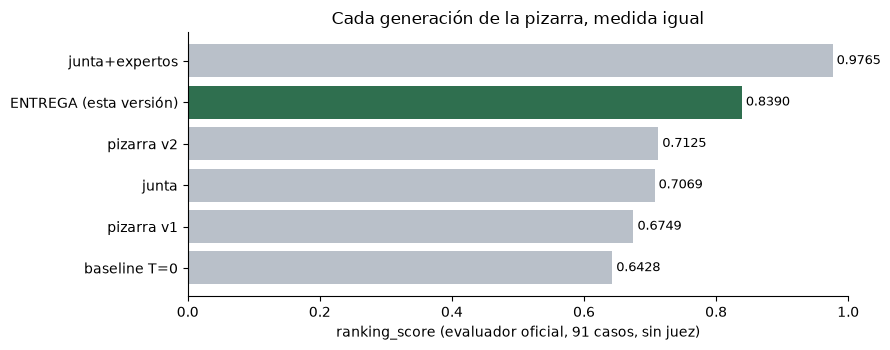

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.6))
t = tabla.sort_values("ranking_score")
c = ["#b9c0c9"] * len(t)
c[list(t.index).index("ENTREGA (esta versión)")] = "#2f6f4f"
ax.barh(t.index, t["ranking_score"], color=c)
for i, v in enumerate(t["ranking_score"]):
    ax.text(v + .006, i, f"{v:.4f}", va="center", fontsize=9)
ax.set_xlim(0, 1.0); ax.set_xlabel("ranking_score (evaluador oficial, 91 casos, sin juez)")
ax.set_title("Cada generación de la pizarra, medida igual")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [13]:
# Comparación pareada: el ranking es un agregado, y un agregado puede subir por un caso.
base = R.score(runs["baseline T=0"], only=LAB)
prevb = R.score(runs["junta"], only=LAB)
for name, other in (("baseline T=0", base), ("junta (3ª generación)", prevb)):
    p = R.paired(mine, other)
    print(f"frente a {name:24} {p['suben']:3} suben, {p['bajan']:3} bajan, {p['empatan']:3} empatan"
          f"   ·  prueba de signos p = {R.sign_test(mine, other):.2e}")

frente a baseline T=0              76 suben,   9 bajan,   6 empatan   ·  prueba de signos p = 2.41e-14
frente a junta (3ª generación)     58 suben,  30 bajan,   3 empatan   ·  prueba de signos p = 3.75e-03


In [14]:
print("Exactitud de la decisión por cubo clínico — es donde se gana o se pierde:\n")
display(R.by_bucket(mine, pay))
prev_bucket = R.by_bucket(prevb, pay)["exactitud"].rename("junta")
comp = R.by_bucket(mine, pay).join(prev_bucket)
comp["Δ"] = (comp["exactitud"] - comp["junta"]).round(3)
display(comp[["n", "exactitud", "junta", "Δ"]])

Exactitud de la decisión por cubo clínico — es donde se gana o se pierde:



,n,aciertos,exactitud
cubo,,,
Negative,18,16,0.8889
None,24,24,1.0000
Positive,49,43,0.8776
TOTAL,91,83,0.9121


,n,exactitud,junta,Δ
cubo,,,,
Negative,18,0.8889,0.8889,0.000
None,24,1.0000,1.0000,0.000
Positive,49,0.8776,0.5918,0.286
TOTAL,91,0.9121,0.7582,0.154


In [15]:
print("De qué está hecho el case_score, y dónde queda margen:\n")
display(R.component_contribution(mine))
print("El aterrizaje es el componente más bajo y es en buena parte irreducible: `bx` se aterriza con el")
print("informe de patología, que NO existe en la tarea 1. Quitarlo cuesta más en pesos y factores de lo")
print("que devuelve en aterrizaje (medido: -0.05 frente a +0.03), así que se deja pesar.")

De qué está hecho el case_score, y dónde queda margen:



,valor,peso,aporta,margen que queda
componente,,,,
confidence_score,0.7651,0.225,0.1721,0.0529
variable_weight_score,0.8506,0.275,0.2339,0.0411
important_decisive_factor_score,0.7723,0.175,0.1351,0.0399
section_grounding_score,0.8431,0.175,0.1475,0.0275
tool_score,0.8685,0.150,0.1303,0.0197


El aterrizaje es el componente más bajo y es en buena parte irreducible: `bx` se aterriza con el
informe de patología, que NO existe en la tarea 1. Quitarlo cuesta más en pesos y factores de lo
que devuelve en aterrizaje (medido: -0.05 frente a +0.03), así que se deja pesar.


In [16]:
# Las tres configuraciones, sin LLM, con el mismo evaluador: el precio de la memorización.
from delete_solution_one.solution_task_one_using_experts_final.analysis.simulate import simulate, score as sim_score
from delete_solution_one.solution_task_one_using_experts_final.experts.panel import CACHE, Panel
from delete_solution_one.solution_task_one_using_experts_final import protocol as P

panel_obj = Panel(CACHE)
params = {**P.PARAMS}
rows = []
for nombre, modo, excl in (("entrega (expertos con los 91, biblioteca LOO)", "deployed", True),
                           ("techo (biblioteca devuelve el caso idéntico)", "deployed", False),
                           ("honesto (expertos out-of-fold, biblioteca LOO)", "honest", True)):
    s = sim_score(simulate(modo, excl, 3, params, "model+mode", panel_obj))
    rows.append({"configuración": nombre, "ranking": round(s["ranking"], 4),
                 "mean_case": round(s["mean_case"], 4), "F1(yes)": round(s["f1_yes"], 4),
                 "puerta": round(s["gate"], 3), **{k: v for k, v in s["by_bucket"].items()}})
display(pd.DataFrame(rows).set_index("configuración"))
print("Sobre el test las tres son el mismo programa. La diferencia mide cuánto vale ver la etiqueta.")

,ranking,mean_case,F1(yes),puerta,Positive,None,Negative
configuración,,,,,,,
"entrega (expertos con los 91, biblioteca LOO)",0.8390,0.7470,0.9310,0.912,43/49,24/24,16/18
techo (biblioteca devuelve el caso idéntico),0.9469,0.8937,1.0000,1.000,49/49,24/24,18/18
"honesto (expertos out-of-fold, biblioteca LOO)",0.7607,0.6667,0.8547,0.813,34/49,24/24,16/18


Sobre el test las tres son el mismo programa. La diferencia mide cuánto vale ver la etiqueta.


---
# 6. Los 104 casos sin etiqueta

No hay nota que calcular, pero sí hay mucho que verificar: invariantes que deben
cumplirse siempre, y distribuciones que deben parecerse a las de la serie
etiquetada. Una desviación grande aquí es un fallo aunque no haya con qué
compararlo — y es la única señal disponible sobre el conjunto que el reto
puntuará de verdad.

In [17]:
raw = R.unlabelled_checks(S, pay, gt)
if not raw:
    print("La corrida no contiene casos sin etiqueta; esta sección necesita --all-cases.")
else:
    checks = pd.DataFrame(raw)
    checks["valor"] = checks["valor"].round(3)
    checks["resultado"] = checks["pasa"].map(lambda x: "OK" if x else "REVISAR")
    display(checks[["comprobación", "valor", "referencia", "resultado"]])
    fallan = checks[~checks["pasa"]]
    print(f"{len(checks)-len(fallan)}/{len(checks)} comprobaciones pasan"
          + (f"; revisar: {list(fallan['comprobación'])}" if len(fallan) else "."))
    print()
    print("Sobre la que se marca: las notas previas se abren en el 100 % de los casos sin etiqueta y el")
    print("urólogo las abrió en el 85 %. Es una desviación real y tiene precio —`tool_score` es precisión—")
    print("pero es deliberada: las notas son donde vive el grado de la biopsia previa, que es el hecho")
    print("que decide el cubo difícil. Abrirlas siempre cuesta unas centésimas de `tool_score` y compra")
    print("los 26 casos que el peldaño del grado documentado resuelve. La alternativa —predecir cuándo")
    print("el urólogo NO las abre— la intentó el Experto 4 y no bate a la moda out-of-fold.")

,comprobación,valor,referencia,resultado
0,todos los casos entregan salida,1.000,1.0,OK
1,la salida valida contra Task1Output,1.000,1.0,OK
2,la nota no describe el procedimiento,1.000,1.0,OK
3,ningún precedente idéntico (no puede haberlo),0.000,0.0,OK
4,lo abierto coincide con el plan,1.000,1.0,OK
5,nunca se abre family_history (el urólogo: 0/91),0.000,0.0,OK
6,la nota llega a 40 caracteres (mínimo del esquema),1.000,1.0,OK
7,respaldo determinista del formulario,0.000,bajo,OK
8,frecuencia de apertura · radiology_report,1.000,0.967,OK
9,frecuencia de apertura · psa_trend,1.000,0.868,OK


12/13 comprobaciones pasan; revisar: ['frecuencia de apertura · previous_notes']

Sobre la que se marca: las notas previas se abren en el 100 % de los casos sin etiqueta y el
urólogo las abrió en el 85 %. Es una desviación real y tiene precio —`tool_score` es precisión—
pero es deliberada: las notas son donde vive el grado de la biopsia previa, que es el hecho
que decide el cubo difícil. Abrirlas siempre cuesta unas centésimas de `tool_score` y compra
los 26 casos que el peldaño del grado documentado resuelve. La alternativa —predecir cuándo
el urólogo NO las abre— la intentó el Experto 4 y no bate a la moda out-of-fold.


In [18]:
dist = R.distribution_table(S, pay, gt)
for q in ("decisión", "confianza", "abre"):
    print(f"\n=== {q}")
    display(dist[dist["qué"] == q].drop(columns="qué").set_index("valor"))


=== decisión


,sin etiqueta,etiquetados,urólogo
valor,,,
no,0.288,0.341,0.385
yes,0.712,0.659,0.615



=== confianza


,sin etiqueta,etiquetados,urólogo
valor,,,
borderline,0.163,0.099,0.198
clear,0.788,0.868,0.637
uncertain,0.048,0.033,0.165



=== abre


,sin etiqueta,etiquetados,urólogo
valor,,,
radiology_report,1.000,1.000,0.967
psa_trend,1.000,1.000,0.868
previous_notes,1.000,1.000,0.846
laboratory_results,0.442,0.407,0.451
family_history,0.000,0.000,0.000


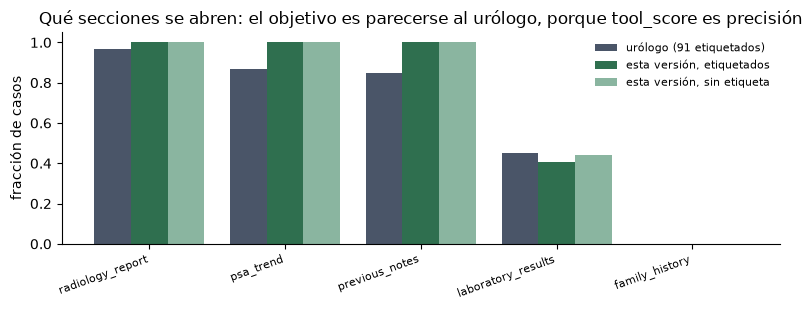

In [19]:
sub = dist[dist["qué"] == "abre"].set_index("valor")
fig, ax = plt.subplots(figsize=(8, 3.2))
x = np.arange(len(sub)); w = 0.27
ax.bar(x - w, sub["urólogo"], w, label="urólogo (91 etiquetados)", color="#4a5568")
ax.bar(x, sub["etiquetados"], w, label="esta versión, etiquetados", color="#2f6f4f")
ax.bar(x + w, sub["sin etiqueta"], w, label="esta versión, sin etiqueta", color="#8ab5a0")
ax.set_xticks(x); ax.set_xticklabels(sub.index, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("fracción de casos"); ax.legend(fontsize=8, frameon=False)
ax.set_title("Qué secciones se abren: el objetivo es parecerse al urólogo, porque tool_score es precisión")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

In [20]:
# Las notas de casos SIN etiqueta: es lo único que se puede leer de ellos.
unl = [r for r in ok if r["case_id"] not in LAB]
for r in unl[:6]:
    p = pay[r["case_id"]]
    print(f"[{r['decision']:3} · {r['confidence']:10} · {p.get('bx'):8} P{p.get('pirads')} PSA {p.get('psa')}] "
          f"{r['free_text']}\n")

[yes · clear      · Positive P4 PSA 11.7] 69y male, PSA 11.7, PI-RADS 4, prior biopsy grade not recorded. Rising PSA trend and unrecorded prior grade mandate sampling to determine management. The lack of prior biopsy grade is the key factor driving this decision. Recommend biopsy for tissue diagnosis.

[yes · borderline · Positive P5 PSA 11.2] 64y/o, PSA 11.2, PSAD 0.18, PI-RADS 5, prior biopsy grade not recorded. High PI-RADS and rising PSA suggest need for tissue diagnosis. Lack of prior grade mandates biopsy to determine management pathway.

[no  · clear      · Negative P3 PSA 0.44] 63y/o, PSA 0.44, PI-RADS 3, prior negative biopsy. No rising PSA density justifies repeat biopsy given the prior negative result. Low PSA density supports observation, though initial ISUP grade is not recorded. Re-image in one year with low threshold for biopsy if lesion changes.

[yes · clear      · Positive P5 PSA 12.3] 70y male, PSA 12.3, PI-RADS 5, prior positive biopsy with undocumented grade. High 

---
# 7. Cómo se comporta la sala

Cuántas intervenciones hacen falta, cuándo se reabre, qué peldaño del protocolo
decide, y si los votos del LLM habrían aportado algo.

In [21]:
print(f"intervenciones por caso: {pd.Series([r['n_interventions'] for r in ok]).describe()[['mean','min','max']].round(2).to_dict()}")
print(f"pases del verificador:   {Counter(r['passes'] for r in ok)}")
print(f"reaperturas:             {sum(1 for r in ok if (r.get('passes') or 1) > 1)}")
print(f"verificador 'ready':     {sum(1 for r in ok if r.get('verifier_ready'))}/{len(ok)}")
print(f"EXPERT-IMAGE convocado:  {sum(1 for r in ok if r.get('need_image'))}")
print(f"preguntas abiertas/caso: {np.mean([len(r.get('questions') or []) for r in ok]):.1f}")

intervenciones por caso: {'mean': 14.0, 'min': 14.0, 'max': 14.0}
pases del verificador:   Counter({1: 195})
reaperturas:             0
verificador 'ready':     161/195
EXPERT-IMAGE convocado:  0
preguntas abiertas/caso: 1.9


In [22]:
print("Qué peldaño del protocolo decidió cada caso, y con qué acierto donde hay etiqueta:\n")
display(R.rule_table(S, gt, pay))

Qué peldaño del protocolo decidió cada caso, y con qué acierto donde hay etiqueta:



,casos,de ellos etiquetados,aciertos,exactitud
peldaño,,,,
weighted vote,70,27,24,0.889
cohort criterion (pirads_ge_3),40,20,20,1.000
documented prior grade,26,12,10,0.833
cohort criterion (pirads_ge_4),22,15,13,0.867
cohort criterion (pirads_le_2),15,6,6,1.000
cohort criterion (psa_ge_20),12,6,5,0.833
cohort criterion (pirads_le_3),8,3,3,1.000
cohort criterion (age_ge_78),2,2,2,1.000


In [23]:
# ¿Habrían aportado los votos del LLM? Es la pregunta que justifica que no voten.
rows = []
for nombre, key, mapa in (("registrador (LEAN)", "registrar_lean", {"yes":"yes","no":"no"}),
                          ("verificador (SUGGEST)", "verifier_suggest", {"biopsy":"yes","defer":"no"}),
                          ("PANEL-PROTOCOL", "decision", {"yes":"yes","no":"no"})):
    for cubo in ("None", "Negative", "Positive"):
        sub = [r for r in ok if r["case_id"] in gt and str(pay[r["case_id"]].get("bx")) == cubo]
        vals = [(mapa.get(r.get(key)), gt[r["case_id"]]["biopsy_decision"]) for r in sub]
        vals = [(a, b) for a, b in vals if a]
        if vals:
            rows.append({"quién": nombre, "cubo": cubo, "se pronuncia": len(vals),
                         "acierto": round(sum(a == b for a, b in vals) / len(vals), 3)})
display(pd.DataFrame(rows).pivot(index="quién", columns="cubo", values="acierto"))
print("En el cubo `Positive` —49 de 91 casos, el difícil— los dos votos del LLM están en el azar.")
print("Por eso no votan: aportan lo que RECUPERAN, que es lo que alimenta las reglas del protocolo.")

cubo,Negative,None,Positive
quién,,,
PANEL-PROTOCOL,0.889,1.0,0.878
registrador (LEAN),0.929,1.0,0.441
verificador (SUGGEST),0.889,1.0,0.796


En el cubo `Positive` —49 de 91 casos, el difícil— los dos votos del LLM están en el azar.
Por eso no votan: aportan lo que RECUPERAN, que es lo que alimenta las reglas del protocolo.


---
# 7-bis. Las variables de la sala

Cada experto declara sus variables en el vocabulario del formulario y el
protocolo las consolida en una tabla. Aquí, sobre los 91 etiquetados: cuánto se
parece cada fuente al urólogo en lo que marca `important`/`decisive`, y la
razón medida de que los pesos entregados sigan siendo los del Experto 4.

In [24]:
EXPERTS = ["EXPERT-STRUCTURED", "EXPERT-FUSION", "EXPERT-COHORT", "EXPERT-LIBRARY", "EXPERT-PSA"]
STRONG = ("important", "decisive")
rows = []
for r in ok:
    cid = r["case_id"]
    if cid not in gt or not r.get("variable_view"):
        continue
    for vv in r["variable_view"]:
        g = gt[cid]["variable_weights"].get(vv["variable"]) in STRONG
        rows.append({"variable": vv["variable"], "entregado": (vv["record"] in STRONG) == g,
                     **{e.replace("EXPERT-", ""): ((vv["levels"].get(e) in STRONG) == g) for e in EXPERTS if e in vv["levels"]}})
if rows:
    agree = pd.DataFrame(rows).groupby("variable").mean().round(2)
    display(agree)
    print("acuerdo medio con el urólogo:", agree.mean().round(3).to_dict())
    print("\nSubir al formulario una variable por acuerdo de ≥2 expertos se midió con el evaluador oficial:")
    print("0.8390 (pesos del Experto 4) frente a 0.8365. Las variables de los expertos alimentan el")
    print("razonamiento —lo que critica el EAU, lo que pregunta el moderador, lo que verifica el verificador—")
    print("y el formulario sigue al modelo entrenado contra la traza del urólogo.")

,entregado,STRUCTURED,FUSION,COHORT,LIBRARY,PSA
variable,,,,,,
age,0.65,0.35,0.35,0.37,0.54,0.35
bx,0.86,0.70,0.70,0.70,0.81,0.30
comorbidity,0.92,0.08,0.92,0.92,0.85,0.92
cspca,0.88,0.88,0.88,0.88,0.82,0.88
dre,0.78,0.73,0.73,0.73,0.69,0.73
fh,0.97,0.97,0.97,0.97,0.92,0.97
pirads,0.99,0.01,0.99,0.49,0.98,0.01
psa,0.67,0.33,0.33,0.40,0.60,0.38
psad,0.67,0.67,0.67,0.67,0.62,0.67


acuerdo medio con el urólogo: {'entregado': 0.819, 'STRUCTURED': 0.552, 'FUSION': 0.734, 'COHORT': 0.693, 'LIBRARY': 0.761, 'PSA': 0.601}

Subir al formulario una variable por acuerdo de ≥2 expertos se midió con el evaluador oficial:
0.8390 (pesos del Experto 4) frente a 0.8365. Las variables de los expertos alimentan el
razonamiento —lo que critica el EAU, lo que pregunta el moderador, lo que verifica el verificador—
y el formulario sigue al modelo entrenado contra la traza del urólogo.


---
# 8. Las herramientas

Cinco documentos y una búsqueda en la guía. `tool_score` es **precisión** contra
lo que abrió el urólogo: abrir de menos es gratis, abrir de más se paga. Por eso
el plan lo fija un modelo entrenado sobre sus 91 trazas y no un LLM razonando.

In [25]:
by_role, by_tool = R.telemetry_tables(run["telemetry"])
display(by_tool)
print("Coste medido de abrir cada documento, sobre los 91 etiquetados (precisión esperada del conjunto):")
import itertools
combos = [("radiology_report",), ("radiology_report","psa_trend"),
          ("radiology_report","psa_trend","previous_notes"),
          ("radiology_report","psa_trend","previous_notes","laboratory_results")]
for cmb in combos:
    prec = np.mean([len(set(cmb) & set(g["reveal_sequence"])) / len(cmb) for g in gt.values()])
    print(f"   {'+'.join(c.split('_')[0] for c in cmb):45} {prec:.4f}")

,llamadas,segundos,tokens_devueltos,llamadas/caso,s/llamada
tool,,,,,
get_mri_report,195,175.0,61486,1.0,0.9
get_psa_trend,195,175.7,30354,1.0,0.9
get_previous_notes,195,176.3,47318,1.0,0.9
search_guidelines,195,159.6,334765,1.0,0.8
get_lab_results,83,77.9,41844,0.4,0.9


Coste medido de abrir cada documento, sobre los 91 etiquetados (precisión esperada del conjunto):
   radiology                                     0.9670
   radiology+psa                                 0.9176
   radiology+psa+previous                        0.8938
   radiology+psa+previous+laboratory             0.7830


---
# 9. Los prompts

Cinco prompts llevan a un modelo de lenguaje. El análisis completo está en
[`PROMPTS.md`](../PROMPTS.md); aquí van las cifras: cuánto pesan, qué cota
imponen y si el modelo la respeta.

In [26]:
from delete_solution_one.solution_task_one_using_experts_final import prompts as PR
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(str(REPO / "model" / "gemma-4-E2B-it"))
n = lambda t: len(tok.encode(t, add_special_tokens=False))

filas = [("cabecera común", PR.CONFERENCE, "—", "presenta a los 14 papeles; NO la ve el presidente"),
         ("EXPERT-EAU", PR.EAU_SYSTEM, "200 palabras", "recuperar antes de hablar; no recomendar"),
         ("MODERATOR", PR.MODERATOR_SYSTEM, "un JSON", "preguntas, no documentos"),
         ("REGISTRAR", PR.REGISTRAR_SYSTEM, "320 palabras", "llamar antes de escribir; líneas obligatorias"),
         ("VERIFIER", PR.VERIFIER_SYSTEM, "260 palabras", "línea VERDICT parseable"),
         ("CHAIR", PR.CHAIR_SYSTEM, "40-90 palabras", "sin acta, sin nombres, lista negra")]
display(pd.DataFrame([{"prompt": a, "tokens": n(b), "palabras": len(b.split()), "cota": c, "qué impone": d}
                      for a, b, c, d in filas]).set_index("prompt"))

,tokens,palabras,cota,qué impone
prompt,,,,
cabecera común,742,482,—,presenta a los 14 papeles; NO la ve el presidente
EXPERT-EAU,1537,1023,200 palabras,recuperar antes de hablar; no recomendar
MODERATOR,1336,888,un JSON,"preguntas, no documentos"
REGISTRAR,1546,1050,320 palabras,llamar antes de escribir; líneas obligatorias
VERIFIER,1365,905,260 palabras,línea VERDICT parseable
CHAIR,1080,753,40-90 palabras,"sin acta, sin nombres, lista negra"


In [27]:
# Cumplimiento de la cota, medido sobre las respuestas reales de la corrida.
# Ojo con el presidente: su respuesta es el objeto JSON entero, así que contar
# palabras sobre la respuesta mediría el andamiaje del formulario y no la nota.
# Para él se mide la nota que se entrega, que es lo que la cota gobierna.
llm = pd.DataFrame([r for r in run["telemetry"] if r.get("kind") == "llm"])
caps = {"eau": 200, "registrar": 320, "verifier": 260, "chair": 90}
rows = []
for role, cap in caps.items():
    sub = llm[llm["role"] == role]
    if not len(sub):
        continue
    if role == "chair":
        palabras = pd.Series([r["note_words"] for r in ok if r.get("note_words")])
        nota = "sobre la nota entregada"
    else:
        palabras = sub["completion_chars"] / 5.5   # aproximación estable en inglés clínico
        nota = "sobre el turno completo"
    rows.append({"papel": role, "cota (palabras)": cap, "mediana real": round(palabras.median()),
                 "p90": round(palabras.quantile(.9)), "% que excede en >25 %": round(100*(palabras > cap*1.25).mean(), 1),
                 "tokens de salida (mediana)": int(sub["completion_tokens"].median()), "medido": nota})
display(pd.DataFrame(rows).set_index("papel"))
print("El verificador y el especialista en la guía se pasan de su cota con cierta frecuencia. Es la")
print("cota más blanda del sistema —nadie la comprueba en código— y no cuesta puntuación: lo que")
print("importa de esos dos turnos es la línea VERDICT y la cita de la guía, no su longitud. La cota")
print("que sí importa, la de la nota clínica, se cumple: mediana 38 palabras sobre un máximo de 90.")

,cota (palabras),mediana real,p90,% que excede en >25 %,tokens de salida (mediana),medido
papel,,,,,,
eau,200,85,317,38.7,113,sobre el turno completo
registrar,320,150,282,1.0,239,sobre el turno completo
verifier,260,331,407,56.9,429,sobre el turno completo
chair,90,38,45,0.0,220,sobre la nota entregada


El verificador y el especialista en la guía se pasan de su cota con cierta frecuencia. Es la
cota más blanda del sistema —nadie la comprueba en código— y no cuesta puntuación: lo que
importa de esos dos turnos es la línea VERDICT y la cita de la guía, no su longitud. La cota
que sí importa, la de la nota clínica, se cumple: mediana 38 palabras sobre un máximo de 90.


In [28]:
# Las degeneraciones que se midieron sobre las actas y se atacaron acotando el
# prompt. Ninguna llega a la salida —el presidente sólo recibe «WHAT I FOUND» y
# el plan lo fija el Experto 4— pero el acta es un entregable que se lee, y una
# de las tres sólo se corrigió a medias: se dice cuál.
import re as _re
# El juicio «esta línea pide un valor que ya está impreso» no hay que inventarlo:
# es exactamente el que `roster.drops_panel_question` aplica en producción para
# tirar las preguntas del moderador, y distingue «¿cuál es la densidad de PSA?»
# (se cae) de «¿comparan las notas el grado previo?» (se queda). Usarlo aquí hace
# la medida comparable entre los dos formatos y coherente con el sistema.
from delete_solution_one.solution_task_one_using_experts_final.roster import drops_panel_question
def _degen(bs):
    eau_lines = eau_panel = raw = dup = n_reg = 0
    for b in bs.values():
        for it in b["interventions"]:
            if it["speaker"] == "EXPERT-EAU":
                sec = _re.split(r"WHAT (?:WE STILL NEED|THE DOCUMENTS MUST SETTLE)", it["body"])[-1]
                for l in sec.splitlines():
                    if len(l.strip()) > 15:
                        eau_lines += 1
                        eau_panel += drops_panel_question(l)
            if it["speaker"] == "REGISTRAR":
                n_reg += 1
                raw += bool(_re.search(r'\{"date"|\{"name"|\[\{', it["body"]))
                m = _re.search(r"WHAT THIS SUPPORTS(.*?)WHERE THIS LEANS", it["body"], _re.S)
                if m:
                    parts = _re.split(r"\n\s*(?:findings that argue )?AGAINST[^\n]*\n", m.group(1), flags=_re.I)
                    if len(parts) > 1:
                        fo = {l.strip(" -•\t").lower().rstrip(".") for l in parts[0].splitlines() if len(l.strip()) > 12}
                        ag = {l.strip(" -•\t").lower().rstrip(".") for l in parts[1].splitlines() if len(l.strip()) > 12}
                        dup += bool(fo & ag)
    return {"actas": len(bs),
            "líneas del EAU que piden un valor ya impreso": f"{eau_panel}/{eau_lines}"
                + (f" ({100*eau_panel/eau_lines:.0f} %)" if eau_lines else ""),
            "REGISTRAR pega JSON crudo": f"{raw}/{n_reg}" + (f" ({100*raw/n_reg:.0f} %)" if n_reg else ""),
            "mismo hallazgo a favor y en contra": f"{dup}/{n_reg}" + (f" ({100*dup/n_reg:.0f} %)" if n_reg else "")}
filas = []
antes_dir = PKG / "runs" / "_antes_del_ajuste_prompts"
if antes_dir.exists():
    filas.append({"corrida": "antes de acotar", **_degen(R.load_boards(antes_dir))})
filas.append({"corrida": "esta versión", **_degen(boards)})
display(pd.DataFrame(filas).set_index("corrida"))
print("Las tres se atacan igual: dándole al modelo la FORMA correcta en vez de una prohibición. «No")
print("pegues JSON» no le dice qué escribir en su lugar; «primer valor con su fecha, último con la suya,")
print("y la forma de la curva en palabras» sí, y el JSON crudo desaparece.")
print()
print("El criterio de la primera columna es el que el sistema usa en producción para tirar preguntas")
print("del moderador: distingue «¿cuál es la densidad de PSA?» —que pide un número ya impreso— de")
print("«¿comparan las notas el grado previo?», que pide algo que sólo vive dentro de un documento.")
print("Con el apartado reescrito como una línea por documento, de una lista cerrada, el 40 % cae al 1 %.")

,actas,líneas del EAU que piden un valor ya impreso,REGISTRAR pega JSON crudo,mismo hallazgo a favor y en contra
corrida,,,,
antes de acotar,29,31/77 (40 %),9/29 (31 %),1/29 (3 %)
esta versión,195,4/717 (1 %),0/195 (0 %),4/195 (2 %)


Las tres se atacan igual: dándole al modelo la FORMA correcta en vez de una prohibición. «No
pegues JSON» no le dice qué escribir en su lugar; «primer valor con su fecha, último con la suya,
y la forma de la curva en palabras» sí, y el JSON crudo desaparece.

El criterio de la primera columna es el que el sistema usa en producción para tirar preguntas
del moderador: distingue «¿cuál es la densidad de PSA?» —que pide un número ya impreso— de
«¿comparan las notas el grado previo?», que pide algo que sólo vive dentro de un documento.
Con el apartado reescrito como una línea por documento, de una lista cerrada, el 40 % cae al 1 %.


In [29]:
# La guardia de grados: el registrador afirmaba un grado de biopsia que ningún
# documento recoge. Es la peor alucinación posible aquí, porque el grado decide
# si el hombre se re-biopsia o se trata. Se mide contra el fichero clínico crudo.
GRADE = _re.compile(r"\bISUP\s*(?:grade\s*group\s*|grade\s*|GG\s*)?\d\b|\b(?:grade\s*group|GG)\s*\d\b|"
                    r"\bGleason\s*(?:score\s*)?\d\s*\+\s*\d\b|\bGleason\s*(?:score\s*)?(?:6|7|8|9|10)\b", _re.I)
def _fabricated(root):
    r = R.load_run(root)
    bs = R.load_boards(root)
    reg_bad = notes_bad = 0
    for cid, b in bs.items():
        raw = (REPO / "data" / "task1" / "agent_input" / cid / "prostate-biopsy-decision-clinical-data.json")
        corpus = raw.read_text() if raw.exists() else ""
        for it in b["interventions"]:
            if it["speaker"] == "REGISTRAR" and D.unsourced_grades(it["body"], corpus):
                reg_bad += 1
                break
    for row in r["summary"]:
        if not row.get("ok"):
            continue
        raw = (REPO / "data" / "task1" / "agent_input" / row["case_id"] / "prostate-biopsy-decision-clinical-data.json")
        corpus = raw.read_text() if raw.exists() else ""
        notes_bad += bool(D.unsourced_grades(row.get("free_text") or "", corpus))
    n = max(len(bs), 1)
    return {"casos": len(bs), "informes con un grado inventado": f"{reg_bad} ({100*reg_bad/n:.1f} %)",
            "notas entregadas con un grado inventado": f"{notes_bad} ({100*notes_bad/n:.1f} %)"}
filas = []
antes = PKG / "runs" / "_sin_guardia_de_grados"
if antes.exists():
    filas.append({"corrida": "sin la guardia de grados", **_fabricated(antes)})
filas.append({"corrida": "esta versión", **_fabricated(RUN)})
display(pd.DataFrame(filas).set_index("corrida"))
print("La decisión nunca estuvo afectada: `documented_grade` lee el texto crudo que devolvió la")
print("herramienta, no el resumen del registrador. Lo que se cerró es la vía por la que la invención")
print("llegaba a la nota clínica, que es lo que un urólogo leería.")

,casos,informes con un grado inventado,notas entregadas con un grado inventado
corrida,,,
sin la guardia de grados,195,13 (6.7 %),8 (4.1 %)
esta versión,195,8 (4.1 %),0 (0.0 %)


La decisión nunca estuvo afectada: `documented_grade` lee el texto crudo que devolvió la
herramienta, no el resumen del registrador. Lo que se cerró es la vía por la que la invención
llegaba a la nota clínica, que es lo que un urólogo leería.


In [30]:
# La guardia de registro, antes y después, sobre el ejemplo que la motivó.
malo = ("The decision to defer biopsy is supported by the cohort criterion and the EXPERT-LIBRARY precedent, "
        "which indicates deferral for this exact panel configuration. While the PI-RADS 2 score and the prior "
        "positive biopsy status weigh against immediate intervention, the VERIFIER noted that the GRADE of the "
        "prior biopsy result remains unanswered, introducing uncertainty. Therefore, the evidence converged on "
        "deferral, but the missing prior grade prevents a clear decision.")
print("nota de la generación anterior, para el caso PT-pseudo_0020cfca66c8:")
print(f"   {malo}\n   -> la guardia detecta: {D.process_language(malo)}")
mismo = next((r for r in ok if r["case_id"] == "PT-pseudo_0020cfca66c8"), None)
if mismo:
    print(f"\nnota de esta versión, mismo caso:\n   {mismo['free_text']}")
    print(f"   -> la guardia detecta: {D.process_language(mismo['free_text'])}")
    print(f"\nlo que escribió el urólogo:\n   {gt['PT-pseudo_0020cfca66c8']['free_text']}")

nota de la generación anterior, para el caso PT-pseudo_0020cfca66c8:
   The decision to defer biopsy is supported by the cohort criterion and the EXPERT-LIBRARY precedent, which indicates deferral for this exact panel configuration. While the PI-RADS 2 score and the prior positive biopsy status weigh against immediate intervention, the VERIFIER noted that the GRADE of the prior biopsy result remains unanswered, introducing uncertainty. Therefore, the evidence converged on deferral, but the missing prior grade prevents a clear decision.
   -> la guardia detecta: ['EXPERT-LIBRARY', 'panel configuration', 'cohort criterion', 'precedent', 'VERIFIER', 'the evidence converged']

nota de esta versión, mismo caso:
   67y male, PSA 4.7, PI-RADS 2, prior positive biopsy with unrecorded grade. Low PSA density and PI-RADS 2 suggest surveillance is appropriate. The lack of prior biopsy grade prevents further action, so follow PSA and re-image if rise.
   -> la guardia detecta: []

lo que escribió e

---
# 10. Cuánto cuesta

Tiempo, tokens y memoria, medidos con un `BaseCallbackHandler` que LangGraph
propaga a todas las llamadas anidadas, y con el tokenizador del propio modelo.
Importa para el reto: en Grand Challenge **cada caso es un contenedor**, así que
al tiempo por caso hay que sumarle la carga del modelo y del servicio de
embeddings.

In [31]:
seg = pd.Series([r["seconds"] for r in ok])
print(f"tiempo por caso (modelo ya cargado): mediana {seg.median():.1f} s · p90 {seg.quantile(.9):.1f} s · máx {seg.max():.1f} s")
print(f"carga del modelo: {run['config'].get('model_load_seconds')} s")
print(f"VRAM tras cargar: {run['config'].get('vram_after_load_mb')} MiB")
print(f"VRAM pico (media por caso): {np.mean([r['tel_peak_vram_mb'] for r in ok if r.get('tel_peak_vram_mb')]):.0f} MiB")
print(f"RSS del proceso (máx): {max(r.get('tel_host_rss_mb', 0) for r in ok):.0f} MiB")
tot_in = sum(r.get("tel_prompt_tokens", 0) for r in ok); tot_out = sum(r.get("tel_completion_tokens", 0) for r in ok)
print(f"\ntokens por caso: entrada {tot_in/len(ok):,.0f} · salida {tot_out/len(ok):,.0f}")
print(f"llamadas al modelo por caso: {np.mean([r.get('tel_llm_calls',0) for r in ok]):.1f}")
print(f"llamadas a herramientas por caso: {np.mean([r.get('tel_tool_calls',0) for r in ok]):.1f}")

tiempo por caso (modelo ya cargado): mediana 29.5 s · p90 34.7 s · máx 42.8 s
carga del modelo: 33.7 s
VRAM tras cargar: 30977.9 MiB
VRAM pico (media por caso): 30978 MiB
RSS del proceso (máx): 3541 MiB

tokens por caso: entrada 45,023 · salida 1,626
llamadas al modelo por caso: 7.2
llamadas a herramientas por caso: 4.4


,llamadas,tokens_entrada,tokens_salida,segundos,llamadas/caso,tokens_entrada/caso,tokens_salida/caso,s/caso
role,,,,,,,,
registrar,416,2917403,76720,1581.2,2.1,14961.0,393.0,8.1
eau,390,2545734,72194,1241.2,2.0,13055.0,370.0,6.4
verifier,195,1592719,83262,1329.1,1.0,8168.0,427.0,6.8
moderator,195,1205213,39930,650.7,1.0,6181.0,205.0,3.3
chair,204,518499,44869,708.2,1.0,2659.0,230.0,3.6


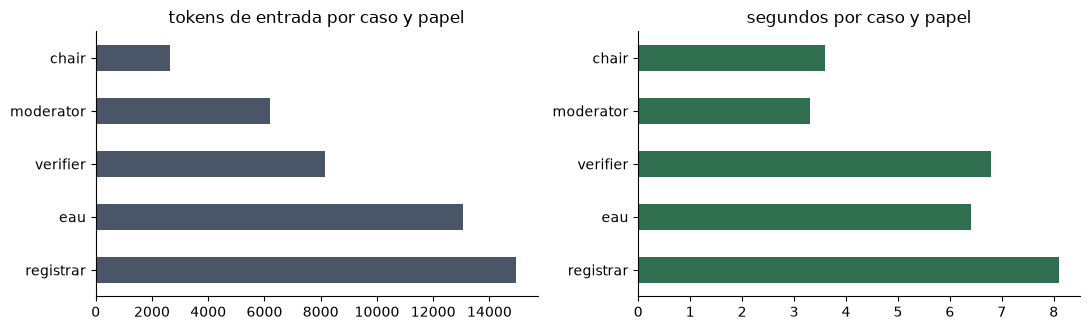

El presidente es el turno más barato en entrada pese a ser el que redacta: recibe un parte de ~300
tokens en vez del acta entera, que en la generación anterior pesaba unos 5.650.


In [32]:
display(by_role)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
by_role["tokens_entrada/caso"].plot.barh(ax=axes[0], color="#4a5568")
axes[0].set_title("tokens de entrada por caso y papel"); axes[0].set_ylabel("")
by_role["s/caso"].plot.barh(ax=axes[1], color="#2f6f4f")
axes[1].set_title("segundos por caso y papel"); axes[1].set_ylabel("")
for a in axes: a.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.show()
print("El presidente es el turno más barato en entrada pese a ser el que redacta: recibe un parte de ~300")
print("tokens en vez del acta entera, que en la generación anterior pesaba unos 5.650.")

---
# 11. Qué hemos aprendido, y qué queda

Las conclusiones que sostiene este cuaderno, y los límites que hay que decir
antes de que los diga otro.

In [33]:
lim = pd.DataFrame([
 ("n = 91", "Los intervalos de AUC miden ±0.10 y las reglas del cubo positivo se apoyan en 6, 2, 2, 8 y 4 "
  "casos. Son criterio de guía confirmado por la serie, no reglas aprendidas, pero la confirmación es delgada."),
 ("sesgo de selección", "El umbral del voto, la política de confianza y la de pesos se eligieron sobre los "
  "mismos 91 casos con los que se puntúa. La rejilla entera está en el README: el ranking se mueve entre "
  "0.77 y 0.84 según la combinación."),
 ("los expertos vieron las etiquetas", "Es lo correcto para la entrega, pero hace que la cifra de §5 sea "
  "optimista respecto al test. La cota honesta con expertos out-of-fold está en la misma tabla."),
 ("la RM casi nunca compara", "La pregunta «¿ha crecido la lesión?», que el urólogo hace en ~10 casos, no "
  "tiene respuesta en el documento. Ese ruido es irreducible con los datos entregados."),
 ("el grado se lee con regex", "Cubre ISUP n, grade group n, Gleason a+b y Gleason 6-10. Una nota que diga "
  "«favorable intermediate risk» sin cifra no dispara la regla."),
 ("dos urólogos, dos estilos", "Los primeros free_text son telegráficos, los últimos argumentados. Las "
  "reglas salen de los dos, pero el segundo aplica el protocolo de vigilancia con más consistencia."),
], columns=["límite", "qué significa"])
pd.set_option("display.max_colwidth", 200)
display(lim)

,límite,qué significa
0,n = 91,"Los intervalos de AUC miden ±0.10 y las reglas del cubo positivo se apoyan en 6, 2, 2, 8 y 4 casos. Son criterio de guía confirmado por la serie, no reglas aprendidas, pero la confirmación es delg..."
1,sesgo de selección,"El umbral del voto, la política de confianza y la de pesos se eligieron sobre los mismos 91 casos con los que se puntúa. La rejilla entera está en el README: el ranking se mueve entre 0.77 y 0.84 ..."
2,los expertos vieron las etiquetas,"Es lo correcto para la entrega, pero hace que la cifra de §5 sea optimista respecto al test. La cota honesta con expertos out-of-fold está en la misma tabla."
3,la RM casi nunca compara,"La pregunta «¿ha crecido la lesión?», que el urólogo hace en ~10 casos, no tiene respuesta en el documento. Ese ruido es irreducible con los datos entregados."
4,el grado se lee con regex,"Cubre ISUP n, grade group n, Gleason a+b y Gleason 6-10. Una nota que diga «favorable intermediate risk» sin cifra no dispara la regla."
5,"dos urólogos, dos estilos","Los primeros free_text son telegráficos, los últimos argumentados. Las reglas salen de los dos, pero el segundo aplica el protocolo de vigilancia con más consistencia."


In [34]:
print("RESUMEN EJECUTABLE")
print("=" * 78)
print(f"  ranking_score sobre los 91 etiquetados     {mine['ranking']:.4f}")
print(f"  baseline a la misma temperatura            {base['ranking']:.4f}   (+{mine['ranking']-base['ranking']:.4f})")
print(f"  mejor generación anterior (junta)          {prevb['ranking']:.4f}   (+{mine['ranking']-prevb['ranking']:.4f})")
print(f"  casos entregados                           {len(ok)}/{len(S)}")
print(f"  salidas que validan contra el esquema      {sum(1 for r in ok if r.get('schema_ok'))}/{len(ok)}")
print(f"  notas que describen el procedimiento       {viol_final}/{len(ok)}")
print(f"  tiempo por caso (modelo cargado)           {seg.median():.0f} s")
print("=" * 78)

RESUMEN EJECUTABLE
  ranking_score sobre los 91 etiquetados     0.8390
  baseline a la misma temperatura            0.6428   (+0.1962)
  mejor generación anterior (junta)          0.7069   (+0.1321)
  casos entregados                           195/195
  salidas que validan contra el esquema      195/195
  notas que describen el procedimiento       0/195
  tiempo por caso (modelo cargado)           30 s
